In [13]:
import pandas as pd
from lifetimes import BetaGeoFitter, GammaGammaFitter
from lifetimes.utils import summary_data_from_transaction_data

# 1. Cargar datos transaccionales
df_sales = pd.read_csv('ecommerce_sales_customer.csv')
df_sales['order_date'] = pd.to_datetime(df_sales['order_date'])

# 2. Formatear matriz para la librería Lifetimes (Recency, Frequency, Monetary)
summary = summary_data_from_transaction_data(
    df_sales, 
    customer_id_col='customer_id', 
    datetime_col='order_date', 
    monetary_value_col='net_sales',
    observation_period_end=df_sales['order_date'].max()
)

# Filtrar clientes con al menos 1 recompra para el modelo Gamma-Gamma
summary_repeat = summary[summary['frequency'] > 0].copy()

# 3. Modelo BG/NBD (Predicción de compras en los próximos 365 días)
bgf = BetaGeoFitter(penalizer_coef=0.01)
bgf.fit(summary['frequency'], summary['recency'], summary['T'])

summary['expected_purchases_365d'] = bgf.conditional_expected_number_of_purchases_up_to_time(
    365, summary['frequency'], summary['recency'], summary['T']
)

# 4. Modelo Gamma-Gamma (Estimación del valor económico pLTV)
ggf = GammaGammaFitter(penalizer_coef=0.01)
ggf.fit(summary_repeat['frequency'], summary_repeat['monetary_value'])

summary_repeat['predicted_clv_12m'] = ggf.customer_lifetime_value(
    bgf,
    summary_repeat['frequency'],
    summary_repeat['recency'],
    summary_repeat['T'],
    summary_repeat['monetary_value'],
    time=12,             # Período proyectado: 12 meses
    discount_rate=0.01   # Tasa de descuento mensual (1%)
)

print("=== RESULTADOS DE LTV PROYECTADO A 12 MESES ===")
print(summary_repeat[['frequency', 'monetary_value', 'predicted_clv_12m']].head())

summary_repeat.to_csv('pltv_proyectado_12meses.csv', index=False)

/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/pandas/core/arraylike.py:402: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


=== RESULTADOS DE LTV PROYECTADO A 12 MESES ===
             frequency  monetary_value  predicted_clv_12m
customer_id                                              
CUST-000001        8.0     1126.392500        1560.452466
CUST-000002        9.0     1775.865556        2751.900345
CUST-000003        6.0     1170.775000        1390.859548
CUST-000004        6.0     1848.753333        3696.651028
CUST-000005        7.0     1118.260000        1481.344585


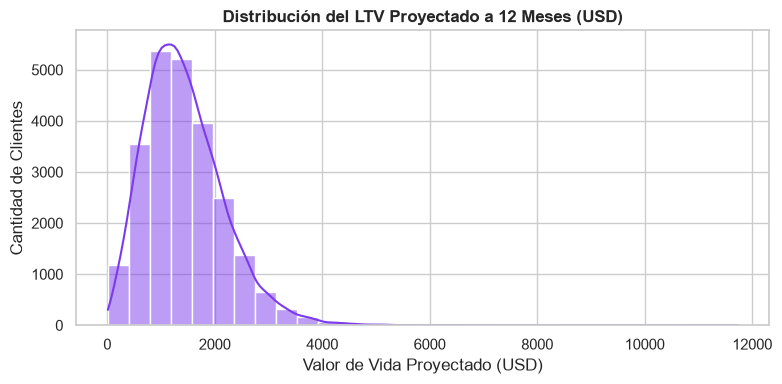

In [14]:
# Histograma con curva de densidad del LTV Proyectado
plt.figure(figsize=(8, 4))
sns.histplot(summary_repeat['predicted_clv_12m'], kde=True, color='#7c3aed', bins=30)
plt.title('Distribución del LTV Proyectado a 12 Meses (USD)', fontsize=12, fontweight='bold')
plt.xlabel('Valor de Vida Proyectado (USD)')
plt.ylabel('Cantidad de Clientes')
plt.tight_layout()
plt.savefig('pltv_distribution.png', dpi=300)
plt.show()

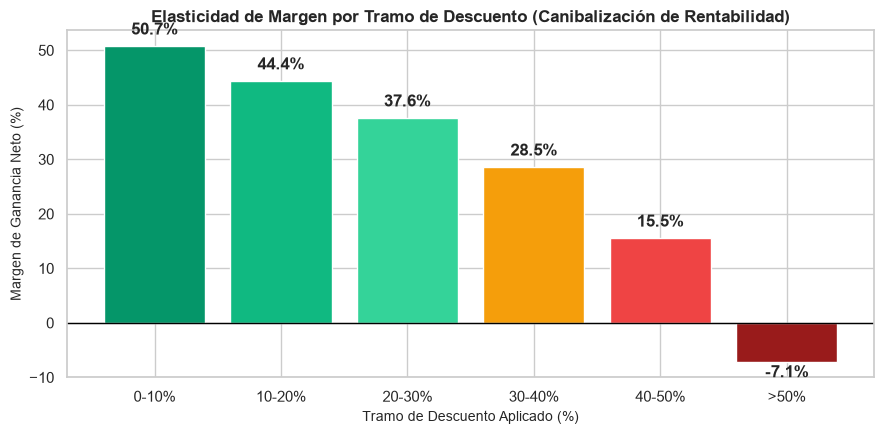

¡Gráfico 'discount_margin_elasticity.png' guardado exitosamente!


In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('order_items.csv')

# 2. Agrupar por tramos de porcentaje de descuento
df['discount_band'] = pd.cut(df['discount_percentage'], 
                             bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0], 
                             labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%'], 
                             include_lowest=True)

discount_summary = df.groupby('discount_band', observed=False).agg(
    total_items=('product_id', 'count'),
    negative_profit_items=('profit', lambda x: (x < 0).sum()),
    total_net_sales=('net_sales', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

discount_summary['margin_pct'] = (discount_summary['total_profit'] / discount_summary['total_net_sales']) * 100

# 3. Graficar Elasticidad de Margen
plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")

colors = ['#059669', '#10b981', '#34d399', '#f59e0b', '#ef4444', '#991b1b']
bars = plt.bar(discount_summary['discount_band'].astype(str), discount_summary['margin_pct'], color=colors)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Elasticidad de Margen por Tramo de Descuento (Canibalización de Rentabilidad)', fontsize=12, fontweight='bold')
plt.xlabel('Tramo de Descuento Aplicado (%)', fontsize=10)
plt.ylabel('Margen de Ganancia Neto (%)', fontsize=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (1.5 if yval>=0 else -3.5), f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('discount_margin_elasticity.png', dpi=300)
plt.show()

print("¡Gráfico 'discount_margin_elasticity.png' guardado exitosamente!")

¡Archivo 'elasticidad_descuentos.csv' guardado con éxito!


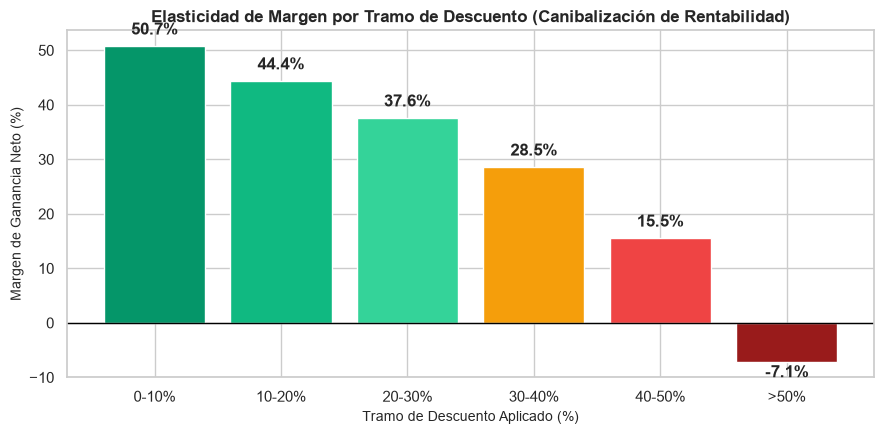

¡Gráfico 'discount_margin_elasticity.png' guardado con éxito!


In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset
df = pd.read_csv('order_items.csv')

# 2. Agrupar por tramos de porcentaje de descuento
df['discount_band'] = pd.cut(df['discount_percentage'], 
                             bins=[0, 0.1, 0.2, 0.3, 0.4, 0.5, 1.0], 
                             labels=['0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%'], 
                             include_lowest=True)

discount_summary = df.groupby('discount_band', observed=False).agg(
    total_items=('product_id', 'count'),
    negative_profit_items=('profit', lambda x: (x < 0).sum()),
    total_net_sales=('net_sales', 'sum'),
    total_profit=('profit', 'sum')
).reset_index()

discount_summary['margin_pct'] = (discount_summary['total_profit'] / discount_summary['total_net_sales']) * 100

# 3. GUARDAR ARCHIVO CSV
discount_summary.to_csv('elasticidad_descuentos.csv', index=False)
print("¡Archivo 'elasticidad_descuentos.csv' guardado con éxito!")

# 4. GENERAR Y GUARDAR GRÁFICO
plt.figure(figsize=(9, 4.5))
sns.set_theme(style="whitegrid")

colors = ['#059669', '#10b981', '#34d399', '#f59e0b', '#ef4444', '#991b1b']
bars = plt.bar(discount_summary['discount_band'].astype(str), discount_summary['margin_pct'], color=colors)

plt.axhline(y=0, color='black', linestyle='-', linewidth=1)
plt.title('Elasticidad de Margen por Tramo de Descuento (Canibalización de Rentabilidad)', fontsize=12, fontweight='bold')
plt.xlabel('Tramo de Descuento Aplicado (%)', fontsize=10)
plt.ylabel('Margen de Ganancia Neto (%)', fontsize=10)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2.0, yval + (1.5 if yval>=0 else -3.5), f"{yval:.1f}%", ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.savefig('discount_margin_elasticity.png', dpi=300)
plt.show()
print("¡Gráfico 'discount_margin_elasticity.png' guardado con éxito!")

¡Archivo 'fuga_operativa.csv' guardado con éxito!


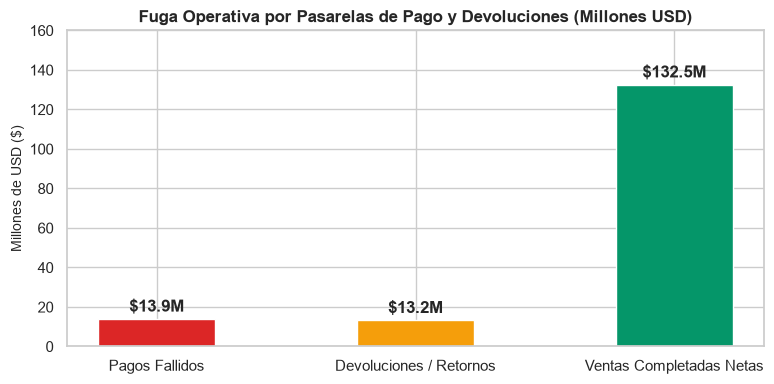

¡Gráfico 'revenue_leakage_friction.png' guardado con éxito!


In [17]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Cargar el dataset
df_sales = pd.read_csv('ecommerce_sales_customer.csv')

# 2. Calcular montos por categoría
failed_sales = df_sales[df_sales['payment_status'] == 'Failed']['net_sales'].sum()
returned_sales = df_sales[df_sales['return_status'] == 'Returned']['net_sales'].sum()
completed_sales = df_sales[df_sales['payment_status'] == 'Paid']['net_sales'].sum()
total_sales = df_sales['net_sales'].sum()

leakage_data = pd.DataFrame([
    {'Categoría': 'Pagos Fallidos', 'Monto_USD': failed_sales, 'Porcentaje_Total': (failed_sales/total_sales)*100},
    {'Categoría': 'Devoluciones / Retornos', 'Monto_USD': returned_sales, 'Porcentaje_Total': (returned_sales/total_sales)*100},
    {'Categoría': 'Ventas Completadas Netas', 'Monto_USD': completed_sales, 'Porcentaje_Total': (completed_sales/total_sales)*100}
])

# 3. GUARDAR ARCHIVO CSV
leakage_data.to_csv('fuga_operativa.csv', index=False)
print("¡Archivo 'fuga_operativa.csv' guardado con éxito!")

# 4. GENERAR Y GUARDAR GRÁFICO
plt.figure(figsize=(8, 4))
colors_leak = ['#dc2626', '#f59e0b', '#059669']
plt.bar(leakage_data['Categoría'], leakage_data['Monto_USD'] / 1e6, color=colors_leak, width=0.45)
plt.title('Fuga Operativa por Pasarelas de Pago y Devoluciones (Millones USD)', fontsize=12, fontweight='bold')
plt.ylabel('Millones de USD ($)', fontsize=10)

for i, v in enumerate(leakage_data['Monto_USD'] / 1e6):
    plt.text(i, v + 2, f"${v:.1f}M", ha='center', va='bottom', fontweight='bold')

plt.ylim(0, 160)
plt.tight_layout()
plt.savefig('revenue_leakage_friction.png', dpi=300)
plt.show()
print("¡Gráfico 'revenue_leakage_friction.png' guardado con éxito!")

¡Archivo 'csat_impacto_logistica.csv' guardado con éxito!


/var/folders/15/2dfz9jxn50n50lj5g67shtqw4m9nvx/T/ipykernel_9518/602131939.py:66: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.tight_layout()
/var/folders/15/2dfz9jxn50n50lj5g67shtqw4m9nvx/T/ipykernel_9518/602131939.py:67: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  plt.savefig('logistics_csat_impact.png', dpi=300)
/Users/gonzalovargas/Library/Python/3.14/lib/python/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 9733 (\N{BLACK STAR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


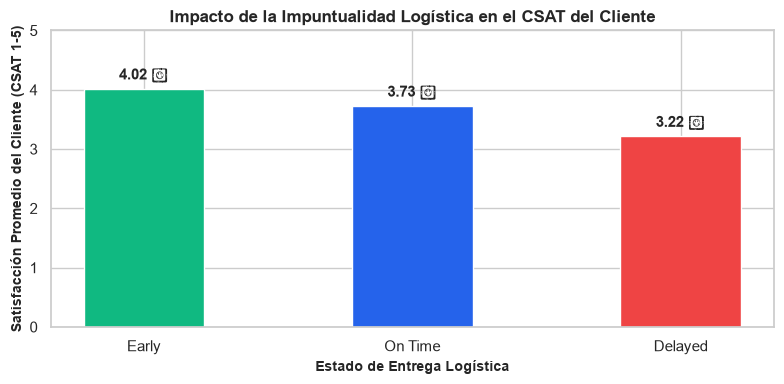

¡Gráfico 'logistics_csat_impact.png' guardado con éxito!


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Cargar el dataset transaccional
df_sales = pd.read_csv('ecommerce_sales_customer.csv')

# 2. Agrupar por estado de entrega logística y calcular estadísticas clave de CSAT
del_df = df_sales[df_sales['delivery_status'] != 'Cancelled'].groupby('delivery_status').agg(
    total_orders=('order_id', 'count'),
    avg_csat=('customer_rating', 'mean'),
    median_csat=('customer_rating', 'median'),
    std_csat=('customer_rating', 'std'),
    avg_delivery_days=('delivery_days', 'mean'),
    avg_estimated_days=('estimated_delivery_days', 'mean')
).reset_index()

# Formatear decimales para exportación ejecutiva
del_df['avg_csat'] = del_df['avg_csat'].round(2)
del_df['median_csat'] = del_df['median_csat'].round(2)
del_df['std_csat'] = del_df['std_csat'].round(2)
del_df['avg_delivery_days'] = del_df['avg_delivery_days'].round(2)
del_df['avg_estimated_days'] = del_df['avg_estimated_days'].round(2)

# 3. GUARDAR ARCHIVO CSV RESUMEN
del_df.to_csv('csat_impacto_logistica.csv', index=False)
print("¡Archivo 'csat_impacto_logistica.csv' guardado con éxito!")

# 4. GENERAR Y GUARDAR EL GRÁFICO
del_df_sorted = del_df.copy()
del_df_sorted['delivery_status'] = pd.Categorical(
    del_df_sorted['delivery_status'], 
    categories=['Early', 'On Time', 'Delayed'], 
    ordered=True
)
del_df_sorted = del_df_sorted.sort_values('delivery_status')

plt.figure(figsize=(8, 4))
sns.set_theme(style="whitegrid")

colors = ['#10b981', '#2563eb', '#ef4444']
bars = plt.bar(
    del_df_sorted['delivery_status'], 
    del_df_sorted['avg_csat'], 
    color=colors, 
    width=0.45
)

plt.ylim(0, 5)
plt.ylabel('Satisfacción Promedio del Cliente (CSAT 1-5)', fontsize=10, fontweight='bold')
plt.xlabel('Estado de Entrega Logística', fontsize=10, fontweight='bold')
plt.title('Impacto de la Impuntualidad Logística en el CSAT del Cliente', fontsize=12, fontweight='bold')

for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2.0, 
        yval + 0.1, 
        f"{yval:.2f} ★", 
        ha='center', 
        va='bottom', 
        fontweight='bold', 
        fontsize=11
    )

plt.tight_layout()
plt.savefig('logistics_csat_impact.png', dpi=300)
plt.show()

print("¡Gráfico 'logistics_csat_impact.png' guardado con éxito!")

In [19]:
import pandas as pd

# 1. Cargar las bases completas de transacciones y reglas
df_sales = pd.read_csv('ecommerce_sales_customer.csv')
df_rules = pd.read_csv('reglas_asociacion_basket.csv')

# 2. Crear Matriz Multidimensional (Agrupación de 138,116 órdenes)
master_data = df_sales.groupby(
    ['marketing_channel', 'customer_segment', 'payment_status', 'delivery_status', 'shipping_method'],
    observed=False
).agg(
    total_ordenes=('order_id', 'count'),
    ventas_netas=('net_sales', 'sum'),
    ganancia_neta=('profit', 'sum'),
    descuento_promedio=('discount_amount', 'mean'),
    costo_envio_promedio=('shipping_cost', 'mean'),
    csat_promedio=('customer_rating', 'mean')
).reset_index()

# Redondear decimales para presentación ejecutiva
master_data['ventas_netas'] = master_data['ventas_netas'].round(2)
master_data['ganancia_neta'] = master_data['ganancia_neta'].round(2)
master_data['descuento_promedio'] = master_data['descuento_promedio'].round(2)
master_data['costo_envio_promedio'] = master_data['costo_envio_promedio'].round(2)
master_data['csat_promedio'] = master_data['csat_promedio'].round(2)

# Exportar dataset maestro multidimensional (1,549 filas de combinaciones analíticas)
master_data.to_csv('master_ecommerce_looker_studio.csv', index=False)

# 3. Exportar Top 100 Reglas de Asociación de Cross-Selling
top_rules = df_rules.head(100).copy()
top_rules.to_csv('top_reglas_cross_selling.csv', index=False)

print("¡Archivos 'master_ecommerce_looker_studio.csv' y 'top_reglas_cross_selling.csv' generados con éxito!")

¡Archivos 'master_ecommerce_looker_studio.csv' y 'top_reglas_cross_selling.csv' generados con éxito!


In [21]:
import pandas as pd

# 1. Cargar las tablas del dataset
df_sales = pd.read_csv('ecommerce_sales_customer.csv')
df_items = pd.read_csv('order_items.csv')
df_cat = pd.read_csv('product_catalog.csv')

# 2. Cruce (Merge) para traer la categoría de producto por ítem y orden
items_cat = df_items.merge(df_cat[['product_id', 'product_category']], on='product_id', how='left')
merged = items_cat.merge(
    df_sales[['order_id', 'marketing_channel', 'customer_segment', 'payment_status', 'delivery_status']], 
    on='order_id', 
    how='left'
)

# 3. Agrupación multidimensional incluyendo product_category
cat_master = merged.groupby(
    ['product_category', 'marketing_channel', 'customer_segment', 'payment_status', 'delivery_status'],
    observed=False
).agg(
    total_ordenes=('order_id', 'nunique'),
    ventas_netas=('net_sales', 'sum'),
    ganancia_neta=('profit', 'sum'),
    descuento_promedio=('discount_amount', 'mean')
).reset_index()

cat_master['ventas_netas'] = cat_master['ventas_netas'].round(2)
cat_master['ganancia_neta'] = cat_master['ganancia_neta'].round(2)
cat_master['descuento_promedio'] = cat_master['descuento_promedio'].round(2)

# 4. Guardar archivo maestro actualizado
cat_master.to_csv('master_ecommerce_looker_studio.csv', index=False)

# Actualizar libro Excel con las dos pestañas
df_rules = pd.read_csv('top_reglas_cross_selling.csv')
with pd.ExcelWriter('Ecosistema_Ecommerce_Consolidado.xlsx') as writer:
    cat_master.to_excel(writer, sheet_name='Master_Ventas_Multidimensional', index=False)
    df_rules.to_excel(writer, sheet_name='Top_Reglas_Cross_Selling', index=False)

print("¡Archivo 'Ecosistema_Ecommerce_Consolidado.xlsx' actualizado con la columna product_category!")

¡Archivo 'Ecosistema_Ecommerce_Consolidado.xlsx' actualizado con la columna product_category!


In [20]:
import pandas as pd

# 1. Cargar las dos tablas procesadas
df_master = pd.read_csv('master_ecommerce_looker_studio.csv')
df_rules = pd.read_csv('top_reglas_cross_selling.csv')

# 2. Exportar a un único libro de Excel con 2 pestañas ordenadas
with pd.ExcelWriter('Ecosistema_Ecommerce_Consolidado.xlsx') as writer:
    df_master.to_excel(writer, sheet_name='Master_Ventas_Multidimensional', index=False)
    df_rules.to_excel(writer, sheet_name='Top_Reglas_Cross_Selling', index=False)

print("¡Archivo 'Ecosistema_Ecommerce_Consolidado.xlsx' generado con éxito con ambas pestañas!")

¡Archivo 'Ecosistema_Ecommerce_Consolidado.xlsx' generado con éxito con ambas pestañas!


In [5]:
# Ver número de productos por pedido en tus datos
items_por_pedido = df_items.groupby('order_id')['product_id'].nunique()
print("Distribución de ítems por pedido:")
print(items_por_pedido.value_counts())

Distribución de ítems por pedido:
product_id
2     38588
3     32927
1     25353
4     20981
5     15110
6      2096
7      1490
8       869
9       443
10      176
11       39
12       24
13       11
14        7
17        1
18        1
Name: count, dtype: int64
